# Particle Size Distributions

In [1]:
import numpy as np
import os
import pyarts3 as pyarts
pyarts.arts.globals.parameters.datapath.append("/home/simon/data/arts-xml-data")

In [2]:
ws = pyarts.Workspace()
ws.surface_fieldPlanet(option="Earth")
ws.surface_field[pyarts.arts.SurfaceKey("t")] = 295.0
ws.atmospheric_fieldRead(
    toa=100e3, basename="planets/Earth/afgl/tropical/", missing_is_zero=1
)
ws.atmospheric_fieldIGRF(time="2000-03-11 14:39:37")

## Single-moment Modified Gamma Distribution

In [3]:
from pyarts3.arts import MGDSingleMoment, ScatteringSpeciesProperty, ParticulateProperty, AtmPoint

rain_first_moment = pyarts.arts.ScatteringSpeciesProperty("rain", pyarts.arts.ParticulateProperty("MassDensity"))
psd = MGDSingleMoment(rain_first_moment, "Field19", 270, 300, False)

point = AtmPoint()
point["t"] = 280
point[rain_first_moment] = 1e-3

sizes = np.logspace(-6, -3, 101)
pnd = psd.evaluate(point, sizes, 1.0, 1.0)

Text(0, 0.5, 'Particle Number Density')

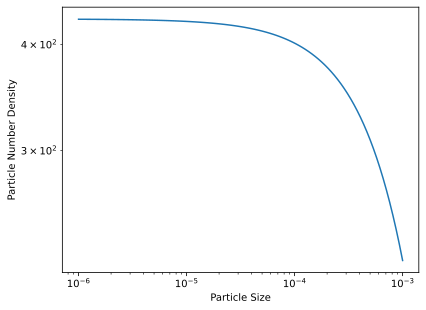

In [4]:
import matplotlib.pyplot as plt
plt.plot(sizes, pnd)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Particle Size")
plt.ylabel("Particle Number Density")

## Binned particles size distribution

In [5]:
from pyarts3.arts import BinnedPSD, SizeParameter

In [6]:
bins = [1e-5, 1e-4, 1e-3]
counts = [1e6, 1e3]
psd = BinnedPSD(SizeParameter("DVeq"), bins, counts, 273.15, 300)
sizes = np.logspace(-6, -3, 101)
pnd = psd.evaluate(point, sizes, 1.0, 1.0)

Text(0, 0.5, 'Particle Number Density')

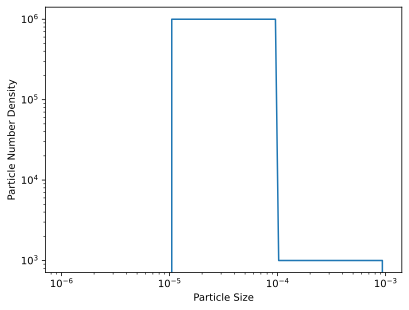

In [7]:
import matplotlib.pyplot as plt
plt.plot(sizes, pnd)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Particle Size")
plt.ylabel("Particle Number Density")